# 🏨 Hotel Cancellation Prediction: Logistic Regression Lab
## Can we predict which bookings will be cancelled before they happen?

---

### The Business Problem

Hotel cancellations are a massive headache for the hospitality industry.  
Consider a hotel with 200 rooms that is fully booked for a Saturday night:

- If **20% of bookings cancel** (a realistic figure), the hotel loses revenue on 40 rooms it could have re-sold.
- If the hotel **overbooks aggressively** and fewer people cancel than expected, it must walk guests to a competitor — destroying customer loyalty.
- You are a data scientist at a fast growing hotel brand and they need a better way to predict cancellations, they have a pretty good size
dataset and would like you to help. If the model works well you get a 10% bonus of all the recovered revenue!  

**A good cancellation-prediction model lets hotels:**
1. **Optimize overbooking** — sell the right number of extra rooms so the hotel fills up even after cancellations.
2.  **Improve staffing** — if 30% of tonight's bookings will cancel, fewer housekeepers and front-desk staff are needed.
3.  **Target at-risk bookings** — reach out proactively with incentives (free breakfast, discount upgrade) to guests who are likely to cancel.

### The Dataset

We are working with the **Hotel Booking Demand** dataset (~119 k real bookings from two Portuguese hotels).  
Our **target variable** is `is_canceled`: `1` if the booking was cancelled, `0` if the guest actually showed up.

### What You Will Build

| Model | Key idea |
|-------|----------|
| **Model 1** | Baseline pipeline — default solver (`lbfgs`), one-hot encoding + min/max scaling |
| **Model 2** | Solver exploration — try using different solvers and see if the model improves |
| **Model 3** | Class-weighted logistic regression + cross-validation to handle imbalanced labels |



---
## 1 · Setup & Data Loading

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)

sns.set_style('whitegrid')

In [46]:
df = pd.read_csv('hotels.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


---
## 2 · Exploratory Data Analysis

Before building any model we need to **understand our data**.  


In [47]:
# Print out summary stats and basic info on the dataset, what trends do you notice?

df.describe() # gives the descriptive statistics of the numerical columns in the dataset

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [48]:
df.info() # gives the summary of the dataset, including the number of non-null values and data types of each column

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [49]:
percentages = df["is_canceled"].value_counts(normalize=True) * 100
# normalized=True converts counts to proportions
print(percentages)

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


In [50]:
df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

In [51]:
# The dataset contains substantial missing data, particularly in the company and agent columns. 
# The cancellation rate is approximately 37.04%, so there's more non-canceled bookings than canceled ones.
# This indicates that the dataset is moderately imbalanced.
# Additionally, the dataset contains a mix of numerical and categorical features, requiring appropriate preprocessing before modeling.

In [52]:
# Calculate prevalence of the target value, how hard of problem is this going to be?

target_prevalence = df['is_canceled'].mean()
print(f'Target prevalence (cancellation rate): {target_prevalence:.2%}')

# The cancellation rate is approximately 37.04%, indicating that the dataset is moderately imbalanced. 
# While there are more non-canceled bookings than canceled ones, the imbalance is not extreme, 
# so it should still be possible to build a predictive model without needing extensive techniques to handle class imbalance.
# However, this imbalance can affect metrics like precision, so it should be considered when evaluating model performance. 
# Overall, the imbalance is not too severe. 

Target prevalence (cancellation rate): 37.04%


---
## 3 · Feature Engineering - Preparation

Before building any model we need to **understand our data**. 

In [53]:
# Check for missing data and drop features with too many missing values, there are some. 

df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

In [54]:
df = df.drop(columns=['company', 'agent']) # drops the 'company' and 'agent' columns 
df = df.dropna(subset=['children', 'country']) # drops the rows where 'children' or 'country' columns have missing values

In [55]:
# There are two other features that need to be dropped because they directly leak the target variable.
# Another way to say this is they represent leakage in the dataset.

df_clean = df.drop(columns=['is_canceled', 'reservation_status', 'reservation_status_date'])
# 'is_canceled' is the target variable, so it cannot be used as a feature for prediction.
# 'reservation_status' and 'reservation_status_date' likely contain information about the cancellation status and date, 
#  which would directly leak the target variable and lead to overly optimistic model performance.

---
### Feature groups, see step 4 in the example (i think it goes 1,2,4 I deleted 3 and didn't change the numbering)

Create lists for the **numerical** and **categorical** so we can apply the right transformations to each group inside a `ColumnTransformer`.

> **Why scale numerics?** Logistic regression uses gradient descent internally.  
> Features on very different scales (e.g. `lead_time` 0–737 vs `adults` 0–4) slow convergence.  
> `StandardScaler` fixes this by converting each feature to mean=0, std=1.

> **Why one-hot encode categoricals?** Logistic regression can't handle strings.  
> One-hot encoding converts each category into its own binary (0/1) column.

Keep in mind that we want to use the pipeline package to handle this preprocessing so create lists of names of numeric and category then pass them into the pipeline, not necessarily creating different dataframes. 



In [56]:
# Prepare for the pipeline make sure to do so for both **numerical** and **categorical**. 
# Generate dataframe for the features and target variable, X and y.

CATEGORICAL = ['hotel', 'arrival_date_year', 'arrival_date_month', 'meal', 'country', 'market_segment', 
                'distribution_channel', 'is_repeated_guest', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
NUMERIC = ['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 
                'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 
                'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
TARGET = 'is_canceled'

X = df_clean[CATEGORICAL + NUMERIC]
# dataframe for the features variable 
y = df[TARGET]
# dataframe for the target variable

In [57]:
# Train / test split — 80/20, stratified so class ratios are preserved 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# stratify=y ensures that the proportion of canceled and non-canceled bookings are the same in both the training and testing sets, 
# which helps to maintain the representativeness of the data.
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

percent_positive_train = y_train.mean() * 100
print(f"Train positive class: {percent_positive_train:.2f}%")
# verifying that stratified splitting worked 

percent_positive_test = y_test.mean() * 100
print(f"Test positive class: {percent_positive_test:.2f}%")
# verifying that stratified splitting worked 

Train: 95118 rows | Test: 23780 rows
Train positive class: 37.13%
Test positive class: 37.14%


---
## 4 · Model Building and Evaluation

Now we are going to build our **model pipeline** and use the transformers

---
Model 1 — Baseline Logistic Regression

Our first pipeline is intentionally **simple**.  
The goal is to establish a baseline score we can try to beat later.
Transformer categorical using one-hot encoding and numerical using the MinMaxscaler()

X_raw  →  ColumnTransformer  →  LogisticRegression(solver='lbfgs')
           (scale + encode)


**`lbfgs`** (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is sklearn's default solver, like we talked about in class

In [58]:
preprocessor_m1 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC) 
])
# preparing the data by applying one-hot encoding to the categorical features and min-max scaling to the numerical features

pipe_m1 = Pipeline(steps=[
    ('prep',  preprocessor_m1),
    ('model', LogisticRegression(max_iter=5000, random_state=42))
])
# creating a pipeline that first preprocesses the data using the defined preprocessor and then fits a logistic regression model with specified parameters

pipe_m1.fit(X_train, y_train)
# fitting the pipeline to the training data
# The logistic regression model is trained on the preprocessed training data, 
# allowing it to learn the relationships between the features and the target variable (cancellation).

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

---
 Model 1 Evaluation: Now that the model is built lets evaluate the model using confusion matrix and ROC/AUC. Give the goal of your assignment how well does the model work?

The Confusion Matrix Will Be Important Evaluation Tool

For a hotel-cancellation problem the four cells of the confusion matrix have real business meaning:?

| | Predicted: Kept | Predicted: Cancelled |
|---|---|---|
| **Actual: Kept** |  **True Negative (TN)** — correctly identified loyal guest |  **False Positive (FP)** — wrongly flagged a loyal guest as a canceller |
| **Actual: Cancelled** |  **False Negative (FN)** — missed a cancellation (costly!) |  **True Positive (TP)** — correctly predicted a cancellation |

**Business impact:**
- **False Negatives** are expensive — we didn't anticipate the cancellation, so we can't fill the room.
- **False Positives** are annoying but cheaper — we might over-staff or over-book slightly.

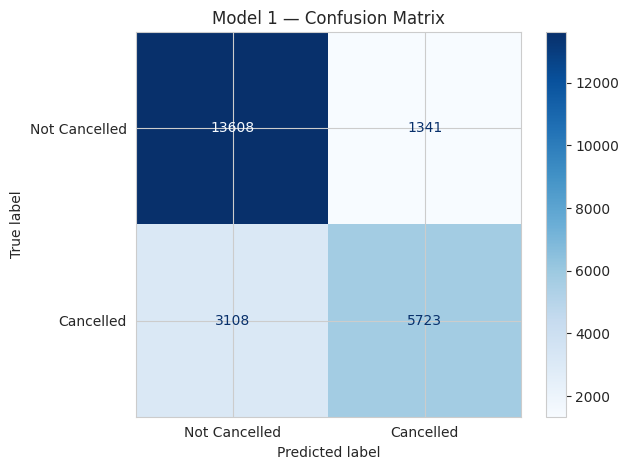

               precision    recall  f1-score   support

Not Cancelled       0.81      0.91      0.86     14949
    Cancelled       0.81      0.65      0.72      8831

     accuracy                           0.81     23780
    macro avg       0.81      0.78      0.79     23780
 weighted avg       0.81      0.81      0.81     23780



In [59]:
y_pred_m1 = pipe_m1.predict(X_test)
# making predictions on the test set using the trained pipeline

# creating the confusion matrix 
cm_m1 = confusion_matrix(y_test, y_pred_m1)
disp_m1 = ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['Not Cancelled', 'Cancelled'])
disp_m1.plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m1, target_names=['Not Cancelled', 'Cancelled']))

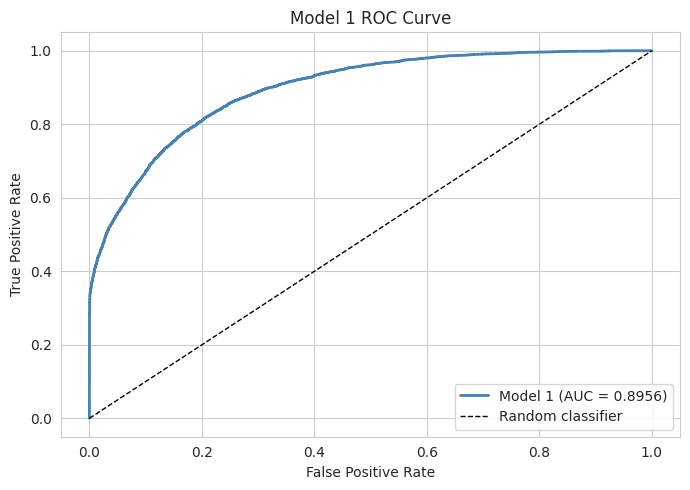

Model 1 ROC-AUC: 0.8956


In [60]:
y_proba_m1 = pipe_m1.predict_proba(X_test)[:, 1]
# getting the predicted probabilities for cancellation from the logistic regression model

fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_proba_m1)
# fpr_m1 : false positive rate 
# tpr_m1 : true positive rate
# threshold : the probability cutoff used to decide 0/1 
auc_m1 = roc_auc_score(y_test, y_proba_m1)
# auc : area under the curve 

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m1, tpr_m1, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc_m1:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 1 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC: {auc_m1:.4f}")

In [61]:
# The model does very well identifying non-cancelled bookings as it has a high recall value of 0.91. 
# The model struggles with identifying canceled bookings as it has a low recall value of 0.65. 
# The model only correctly identifies 65% of actual cancellations, 
# which is a concern for the business because it means that 35% of cancellations are being missed.
# ROC curve confirms that the model performs better than random guessing, 
# but there is still room for improvement in distinguishing between cancelled and non-cancelled bookings.

---
## 5 · Model 2 — Exploring Different Solvers 

- Adjust your model object in the pipeline then evaluate again using confusion matrix and ROC/AUC. Make sure to eval on the test set. You should create a model_2_pipe, use much of the same code but create a new pipeline for each model

Sklearn's `LogisticRegression` supports several **solvers** (optimisation algorithms) and  
**regularisation strategies** controlled by `l1_ratio` and `C`.

| Solver | Best for |
|--------|----------|
| `lbfgs` | Default; works well on most datasets (L2 regularisation) |
| `liblinear` | Smaller datasets; supports L1 via `l1_ratio=1` |
| `saga` | Large datasets; supports L1, L2, and ElasticNet |


Did the model improve based on the various solvers?



In [62]:
preprocessor_m2 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC) 
])

pipe_m2_liblinear = Pipeline(steps=[
    ('prep',  preprocessor_m2),
    ('model', LogisticRegression(solver="liblinear",max_iter=5000, random_state=42))
])

pipe_m2_liblinear.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

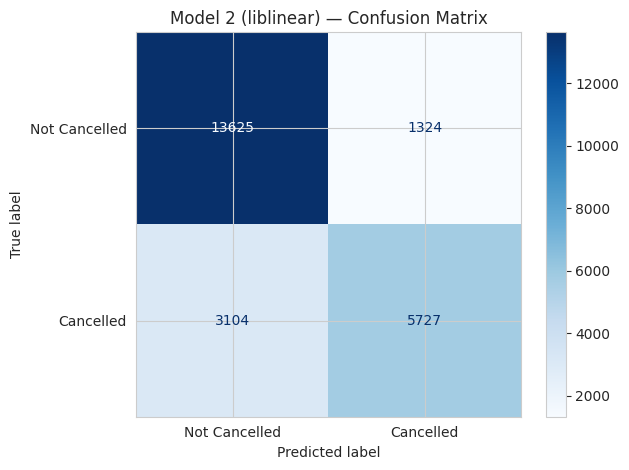

               precision    recall  f1-score   support

Not Cancelled       0.81      0.91      0.86     14949
    Cancelled       0.81      0.65      0.72      8831

     accuracy                           0.81     23780
    macro avg       0.81      0.78      0.79     23780
 weighted avg       0.81      0.81      0.81     23780



In [63]:
y_pred_m2_liblinear = pipe_m2_liblinear.predict(X_test)
cm_m2 = confusion_matrix(y_test, y_pred_m2_liblinear)
disp_m2 = ConfusionMatrixDisplay(confusion_matrix=cm_m2, display_labels=['Not Cancelled', 'Cancelled'])
disp_m2.plot(cmap='Blues')
plt.title('Model 2 (liblinear) — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m2_liblinear, target_names=['Not Cancelled', 'Cancelled']))

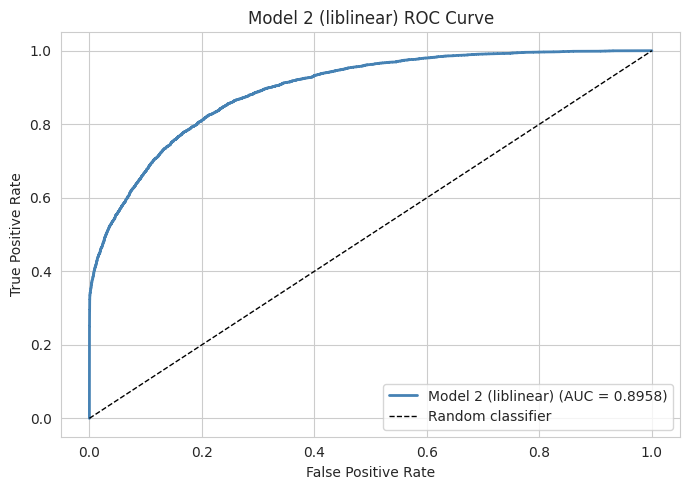

Model 2 (liblinear) ROC-AUC: 0.8958


In [64]:
y_proba_m2_liblinear = pipe_m2_liblinear.predict_proba(X_test)[:, 1]

fpr_m2, tpr_m2, thresholds = roc_curve(y_test, y_proba_m2_liblinear)
auc_m2 = roc_auc_score(y_test, y_proba_m2_liblinear)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m2, tpr_m2, lw=2, color='steelblue', label=f'Model 2 (liblinear) (AUC = {auc_m2:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 2 (liblinear) ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 2 (liblinear) ROC-AUC: {auc_m2:.4f}")

In [65]:
pipe_m2_saga = Pipeline(steps=[
    ('prep',  preprocessor_m2),
    ('model', LogisticRegression(solver="saga", max_iter=5000, random_state=42))
])

pipe_m2_saga.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

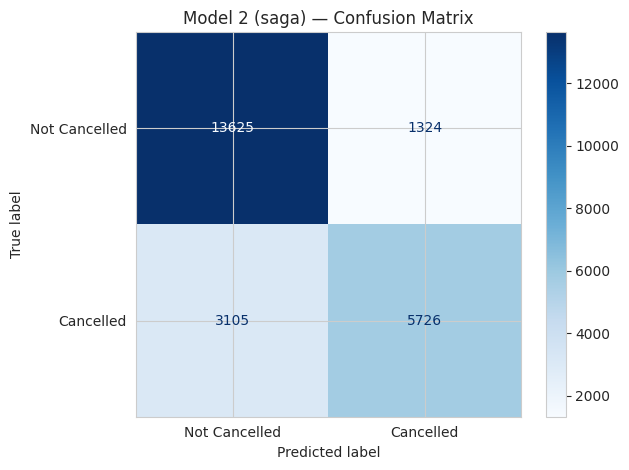

               precision    recall  f1-score   support

Not Cancelled       0.81      0.91      0.86     14949
    Cancelled       0.81      0.65      0.72      8831

     accuracy                           0.81     23780
    macro avg       0.81      0.78      0.79     23780
 weighted avg       0.81      0.81      0.81     23780



In [66]:
y_pred_m2_saga = pipe_m2_saga.predict(X_test)
cm_m2 = confusion_matrix(y_test, y_pred_m2_saga)
disp_m2 = ConfusionMatrixDisplay(confusion_matrix=cm_m2, display_labels=['Not Cancelled', 'Cancelled'])
disp_m2.plot(cmap='Blues')
plt.title('Model 2 (saga) — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m2_saga, target_names=['Not Cancelled', 'Cancelled']))

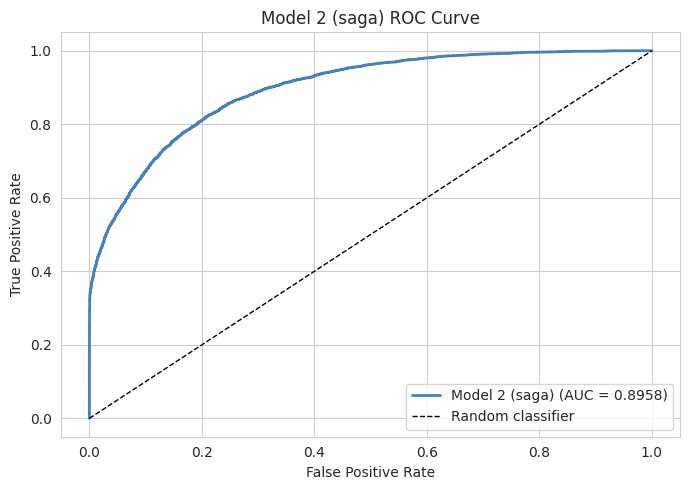

Model 2 (saga) ROC-AUC: 0.8958


In [67]:
y_proba_m2_saga = pipe_m2_saga.predict_proba(X_test)[:, 1]

fpr_m2, tpr_m2, thresholds = roc_curve(y_test, y_proba_m2_saga)
auc_m2 = roc_auc_score(y_test, y_proba_m2_saga)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m2, tpr_m2, lw=2, color='steelblue', label=f'Model 2 (saga) (AUC = {auc_m2:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 2 (saga) ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 2 (saga) ROC-AUC: {auc_m2:.4f}")

In [68]:
# The model did not improve or worsen based on the various solvers.
# The solvers produced the same precision, recall, F1-score, and AUC scores, 
# indicating that changing the solver did not lead to a noticeable difference in model performance.
# This is because changing the solver does not change the underlying model,
# but rather how the logistic regression algorithm optimizes the coefficients.

---
## 6 · Model 3 — Balanced Class Weights + Cross-Validation

Build a final model (pipe_3) with a balanced class weight and use cross validation. As a reminder cv happens on the fit process not as part of the pipeline and we need to build our CV object, similar to the model object.

Use the example shown in class to see how to apply cross validation, balanced weight is a argument in the logreg function that you just need to apply as seen below. 

### The Class Imbalance Problem

Our dataset has ~63% non-cancellations and ~37% cancellations.  
A lazy model could achieve 63% accuracy by *always* predicting "Kept"!  
We saw that Models 1 and 2 sometimes struggled with **recall on the cancelled class**.

### Solution: `class_weight='balanced'`

Setting `class_weight='balanced'` tells sklearn to automatically weight the training samples  
so that the minority class (cancellations) gets more attention during training.

Specifically, each class gets weight = `n_samples / (n_classes × n_samples_in_class)`.

### Solution: Cross-Validation

Instead of a single train/test split (which can be lucky or unlucky),  
**k-fold cross-validation** trains and evaluates the model on `k` different splits  
and reports the average — giving a much more reliable estimate of real-world performance.

```
Fold 1: [train | train | train | train | VAL ]
Fold 2: [train | train | train | VAL  | train]
Fold 3: [train | train | VAL  | train | train]
...and so on
```

---

### Experiments

- Change the number of folds from `5` to `10` — does the mean AUC change much?
- Try removing `class_weight='balanced'` — what happens to recall on the cancelled class?

In [69]:
preprocessor_m3 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC) 
])

pipe_m3 = Pipeline(steps=[
    ('prep',  preprocessor_m3),
    ('model', LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced'))
])
# class_weight="balanced" helps the model handle imbalanced data by making it care more about the 
# minority class (cancelled bookings), so it doesn't just always predict the majority 

5-Fold Cross-Validation Results :
  ROC-AUC : 0.8936  ± 0.0015  | folds: [0.8924 0.8934 0.8924 0.8933 0.8965]


/tmp/ipykernel_32343/4045777766.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([cv_auc], labels=['AUC'], patch_artist=True,


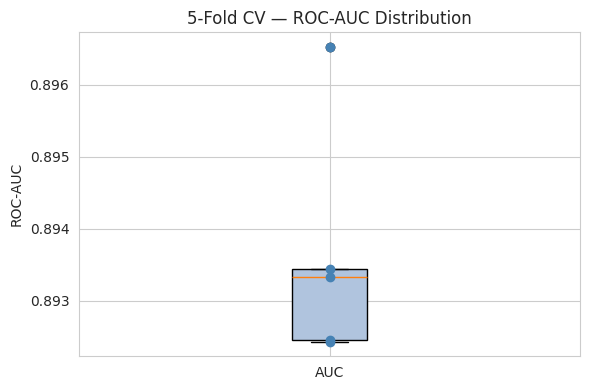

In [70]:
# cross-validation 
# a single train/test split might be lucky or unlucky where your model could perform unusually well or poorly 
# depending on that split. 
# cross validation is a way to test your model's performance on different subsets of the data. 
# the data is split into n number of folds. 
# for each iteration, one fold acts as the test set, while the remaining folds act as the training set. 
# this process rotates the test fold so that each fold is used once for testing. 

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# splits the data into 5 folds while preserving the cancelled/non-cancelled class ratios in each fold 

cv_auc  = cross_val_score(pipe_m3, X, y, cv=cv, scoring='roc_auc')
# trains and evaluates the pipeline 5 times (once for each fold) 
# cv_auc contains the ROC-AUC scores for each of the 5 folds

print("5-Fold Cross-Validation Results :")
print(f"  ROC-AUC : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}  | folds: {np.round(cv_auc, 4)}")

# Box-plot of fold AUCs
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([cv_auc], labels=['AUC'], patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'))
ax.scatter([1]*5, cv_auc, color='steelblue', zorder=3)
ax.set_title('5-Fold CV — ROC-AUC Distribution')
ax.set_ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

10-Fold Cross-Validation Results :
  ROC-AUC : 0.8938  ± 0.0025  | folds: [0.8953 0.8903 0.8946 0.8921 0.8903 0.895  0.8922 0.8953 0.8941 0.8988]


/tmp/ipykernel_32343/225178447.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([cv_auc_ten], labels=['AUC'], patch_artist=True,


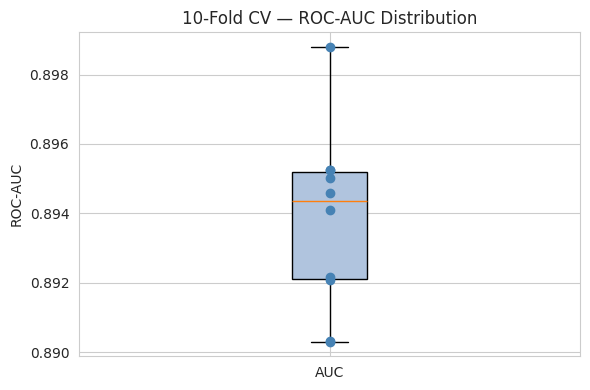

In [71]:
cv_ten = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
# splits the data into 10 folds while preserving the cancelled/non-cancelled class ratios in each fold 

cv_auc_ten  = cross_val_score(pipe_m3, X, y, cv=cv_ten, scoring='roc_auc')
# trains and evaluates the pipeline 10 times (once for each fold) 
# cv_auc contains the ROC-AUC scores for each of the 10 folds

print("10-Fold Cross-Validation Results :")
print(f"  ROC-AUC : {cv_auc_ten.mean():.4f}  ± {cv_auc_ten.std():.4f}  | folds: {np.round(cv_auc_ten, 4)}")

# Box-plot of fold AUCs
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([cv_auc_ten], labels=['AUC'], patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'))
ax.scatter([1]*10, cv_auc_ten, color='steelblue', zorder=3)
ax.set_title('10-Fold CV — ROC-AUC Distribution')
ax.set_ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

In [72]:
# The mean AUC does not change much between 5-fold and 10-fold cross-validation
# (changes by 0.0002), but the standard deviation decreases with 10-fold CV (by 0.001). 

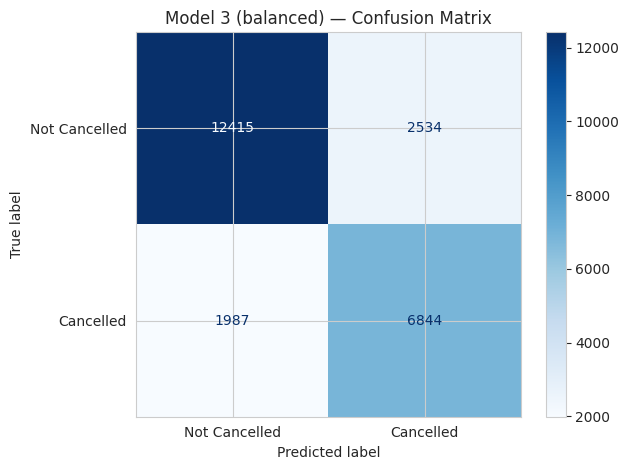

               precision    recall  f1-score   support

Not Cancelled       0.86      0.83      0.85     14949
    Cancelled       0.73      0.77      0.75      8831

     accuracy                           0.81     23780
    macro avg       0.80      0.80      0.80     23780
 weighted avg       0.81      0.81      0.81     23780



In [73]:
pipe_m3.fit(X_train, y_train)

y_pred_m3 = pipe_m3.predict(X_test)
cm_m3 = confusion_matrix(y_test, y_pred_m3)
disp_m3 = ConfusionMatrixDisplay(confusion_matrix=cm_m3, display_labels=['Not Cancelled', 'Cancelled'])
disp_m3.plot(cmap='Blues')
plt.title('Model 3 (balanced) — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m3, target_names=['Not Cancelled', 'Cancelled']))

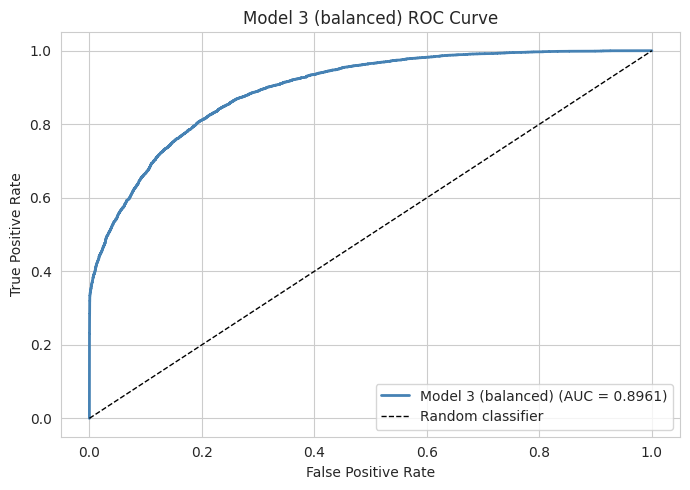

Model 3 (balanced) ROC-AUC: 0.8961


In [74]:
y_proba_m3_balanced = pipe_m3.predict_proba(X_test)[:, 1]

fpr_m3, tpr_m3, thresholds = roc_curve(y_test, y_proba_m3_balanced)
auc_m3 = roc_auc_score(y_test, y_proba_m3_balanced)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m3, tpr_m3, lw=2, color='steelblue', label=f'Model 3 (balanced) (AUC = {auc_m3:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 3 (balanced) ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 3 (balanced) ROC-AUC: {auc_m3:.4f}")

In [75]:
preprocessor_m3_unbalanced = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC) 
])

pipe_m3_unbalanced = Pipeline(steps=[
    ('prep',  preprocessor_m3_unbalanced),
    ('model', LogisticRegression(max_iter=5000, random_state=42))
])

pipe_m3_unbalanced.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

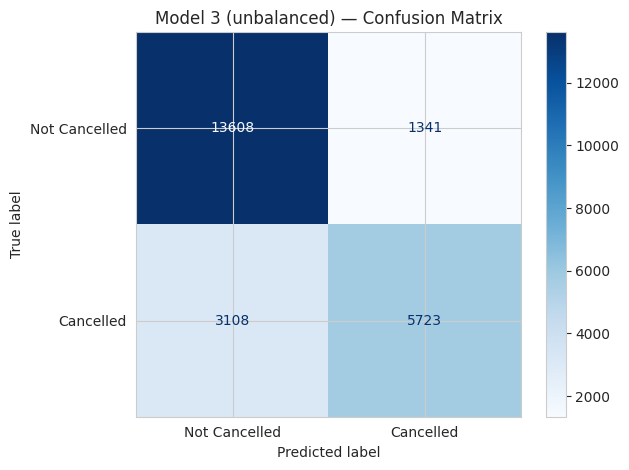

               precision    recall  f1-score   support

Not Cancelled       0.81      0.91      0.86     14949
    Cancelled       0.81      0.65      0.72      8831

     accuracy                           0.81     23780
    macro avg       0.81      0.78      0.79     23780
 weighted avg       0.81      0.81      0.81     23780



In [76]:
y_pred_m3_unbalanced = pipe_m3_unbalanced.predict(X_test)
cm_m3_unbalanced = confusion_matrix(y_test, y_pred_m3_unbalanced)
disp_m3_unbalanced = ConfusionMatrixDisplay(confusion_matrix=cm_m3_unbalanced, display_labels=['Not Cancelled', 'Cancelled'])
disp_m3_unbalanced.plot(cmap='Blues')
plt.title('Model 3 (unbalanced) — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m3_unbalanced, target_names=['Not Cancelled', 'Cancelled']))

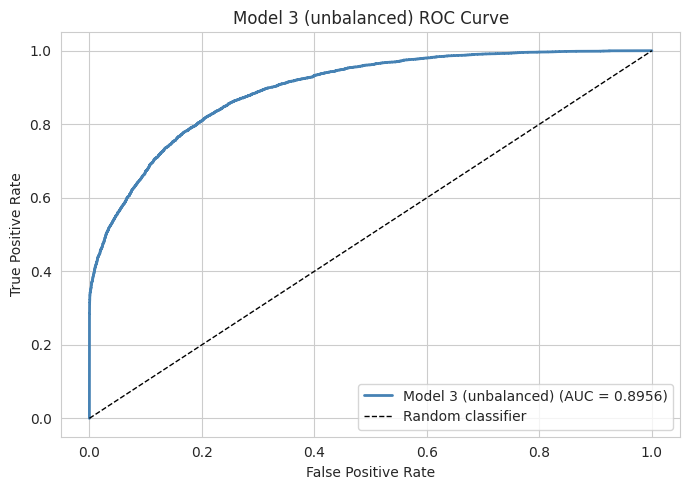

Model 3 (unbalanced) ROC-AUC: 0.8956


In [77]:
y_proba_m3_unbalanced = pipe_m3_unbalanced.predict_proba(X_test)[:, 1]

fpr_m3, tpr_m3, thresholds = roc_curve(y_test, y_proba_m3_unbalanced)
auc_m3 = roc_auc_score(y_test, y_proba_m3_unbalanced)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m3, tpr_m3, lw=2, color='steelblue', label=f'Model 3 (unbalanced) (AUC = {auc_m3:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 3 (unbalanced) ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 3 (unbalanced) ROC-AUC: {auc_m3:.4f}")

In [78]:
# When class_weight="balanced" is removed, recall on the cancelled class 
# drops from 0.77 to 0.65, which means that the model is now only correctly identifying 65% of actual cancellations,
# compared to 77% when class_weight="balanced" is used.

---
## 07 · Summary & Reflection

### What We Learned

**Model Performance**
- Which model worked best and why do you think that is the case? Write a short recommendation to your boss on how to proceed (1 paragraph)

### Challenge Extensions - extra 5 points for each

If you want to push further:

1. **Tune `C`** using `GridSearchCV` over the range `[0.001, 0.01, 0.1, 1, 10, 100]`.
2. **Engineer new features** — e.g. `total_nights = stays_in_weekend_nights + stays_in_week_nights`.
3. **Try a different model** — replace `LogisticRegression` in the pipeline with `RandomForestClassifier` or `GradientBoostingClassifier`. Does AUC improve? or maybe kNN
4. **Interpret coefficients** — given that the variables have been standardized create a horizontal bar chart showing
the rankings of the coeficients 

---

In [79]:
# Which model worked best? 

# After creating several logistic regression models, model 3 with class_weight="balanced"
# performed the best. The dataset is moderately imbalanced, with approximately 37% of bookings 
# canceled and 63% not canceled. By setting class_weight="balanced", the model automatically 
# gives more weight to the minority class (cancellations) during training to account for 
# the imbalance in the dataset. As a result, model 3 with class_weight="balanced" achieved a 
# recall of 0.77 for the cancelled class, correctly identifying 77% of bookings that are likely 
# to cancel compared to only 65% for the unbalanced models. While it slightly reduces the recall 
# for the non-cancelled bookings, this trade-off is acceptable because missed cancellations are 
# far more costly to the hotel than overestimating cancellations. Based on these results, I 
# recommend deploying model 3 with class_weight="balanced" than the other models to flag at-risk 
# bookings in advance. Doing so will allow the hotel to optimize overbooking, improve staffing 
# decisions, and proactively reach out to guests likely to cancel, ultimately reducing lost revenue 
# and improving operational efficiency.

In [80]:
# 1. Tune C 

from sklearn.model_selection import GridSearchCV

pipe_tune = Pipeline(steps=[
    ('prep', preprocessor_m3),
    ('model', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42))
])

param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=pipe_tune, 
    param_grid=param_grid, 
    scoring='roc_auc',
    cv=5, n_jobs=-1, 
    verbose=1
)
# GridSearchCV automatically tests multiple combinations of hyperparameters to find the best model.
# CV in GridSearchCV : evaluating each hyperparameter combination using cross-validation to avoid overfitting.

grid_search.fit(X_train, y_train)
# Runs logistic regression with each C value using 5-fold CV on the training set
# and calculates the mean ROC-AUC for each C

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candida

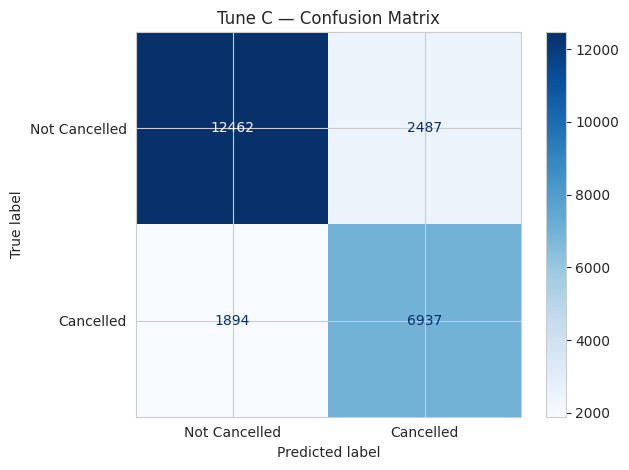

               precision    recall  f1-score   support

Not Cancelled       0.87      0.83      0.85     14949
    Cancelled       0.74      0.79      0.76      8831

     accuracy                           0.82     23780
    macro avg       0.80      0.81      0.81     23780
 weighted avg       0.82      0.82      0.82     23780



In [81]:
y_pred_c= grid_search.predict(X_test)
cm_m_c = confusion_matrix(y_test, y_pred_c)
disp_m_c = ConfusionMatrixDisplay(confusion_matrix=cm_m_c, display_labels=['Not Cancelled', 'Cancelled'])
disp_m_c.plot(cmap='Blues')
plt.title('Tune C — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_c, target_names=['Not Cancelled', 'Cancelled']))

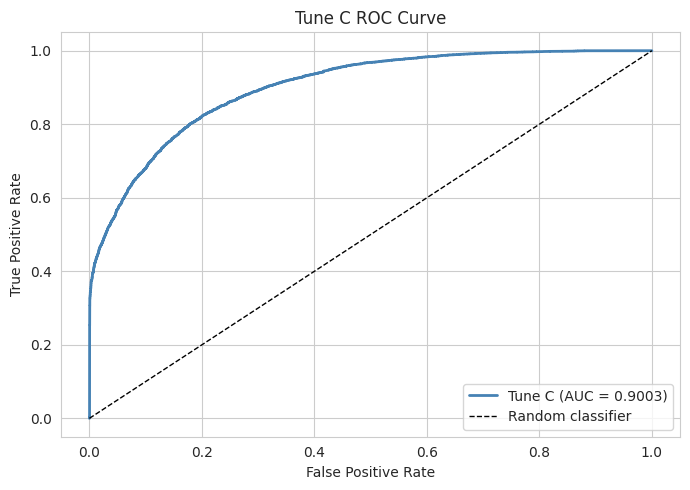

Tune C ROC-AUC: 0.9003


In [82]:
y_proba_c = grid_search.predict_proba(X_test)[:, 1]

fpr_c, tpr_c, thresholds = roc_curve(y_test, y_proba_c)
auc_c = roc_auc_score(y_test, y_proba_c)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_c, tpr_c, lw=2, color='steelblue', label=f'Tune C (AUC = {auc_c:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Tune C ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Tune C ROC-AUC: {auc_c:.4f}")

In [83]:
# This model performed slightly better than model 3 with class_weight="balanced" with a recall of 
# 0.79 for the cancelled class, correctly identifying 79% of bookings that are likely to cancel.
# It also produced a slightly higher AUC score of 0.9003 compared to 0.8961 for model 3 with class_weight="balanced".

In [84]:
# 2. Engineer new features 

df["total_nights"] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [85]:
# 3. Try a different model 

from sklearn.ensemble import RandomForestClassifier

preprocessor_dm = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC) 
])

pipe_dm = Pipeline(steps=[
    ('prep', preprocessor_dm),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe_dm.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

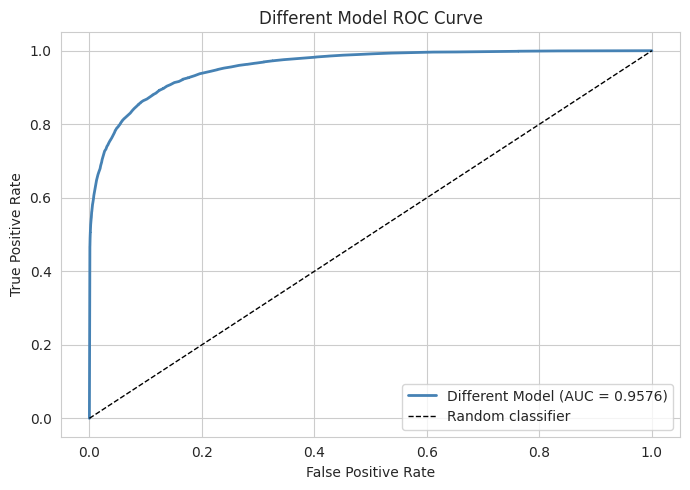

Different Model ROC-AUC: 0.9576


In [86]:
y_proba_dm = pipe_dm.predict_proba(X_test)[:, 1]

fpr_dm, tpr_dm, thresholds = roc_curve(y_test, y_proba_dm)
auc_dm = roc_auc_score(y_test, y_proba_dm)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_dm, tpr_dm, lw=2, color='steelblue', label=f'Different Model (AUC = {auc_dm:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Different Model ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Different Model ROC-AUC: {auc_dm:.4f}")

In [87]:
# The AUC does improve from 0.8961 of model 3 with class_weight="balanced" to 0.9576 with the random forest model. 

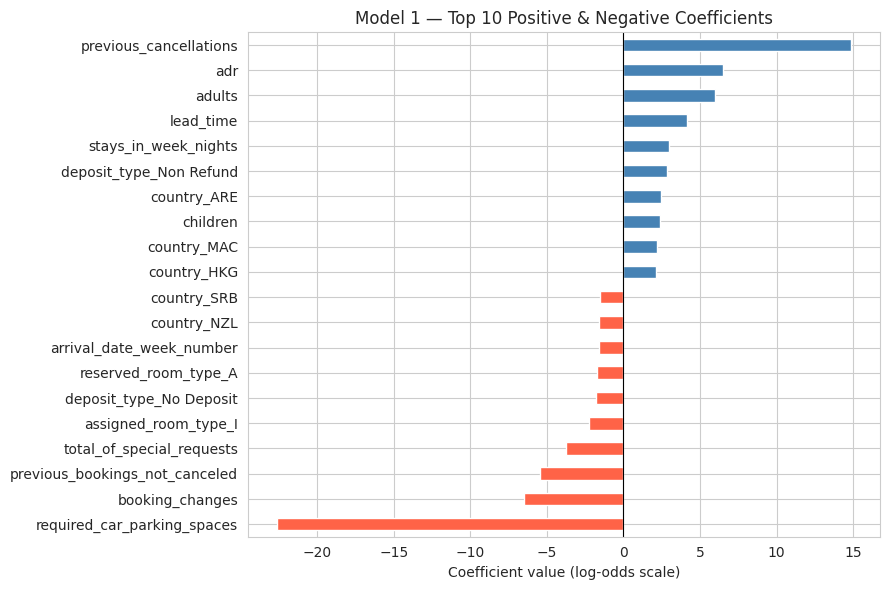

In [88]:
# 4. Interpret coefficients 

ohe_features = pipe_m1.named_steps['prep'].transformers_[0][1].get_feature_names_out(CATEGORICAL)
feature_names_m1 = list(ohe_features) + NUMERIC
coefs_m1 = pd.Series(
    pipe_m1.named_steps['model'].coef_[0],
    index=feature_names_m1
).sort_values()

# Show top 10 positive and top 10 negative
top_coefs = pd.concat([coefs_m1.head(10), coefs_m1.tail(10)])
top_coefs.plot(kind='barh', figsize=(9, 6), color=top_coefs.map(lambda v: 'steelblue' if v >= 0 else 'tomato'))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Model 1 — Top 10 Positive & Negative Coefficients')
plt.xlabel('Coefficient value (log-odds scale)')
plt.tight_layout()
plt.show()